In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

FIGURE_DIR = './figures/nb02'
os.makedirs(FIGURE_DIR, exist_ok=True)

# %%
df = pd.read_parquet('./data/chicago_crimes_clean.parquet')
print(f"Loaded: {len(df):,} rows, {df.shape[1]} cols")
print(f"Time range: {df['year'].min():.0f} - {df['year'].max():.0f}")

df = df[(df['year'] >= 2001) & (df['year'] <= 2025)].copy()
print(f"After filtering 2001-2025: {len(df):,} rows")

Loaded: 8,408,989 rows, 21 cols
Time range: 2001 - 2026
After filtering 2001-2025: 8,367,792 rows


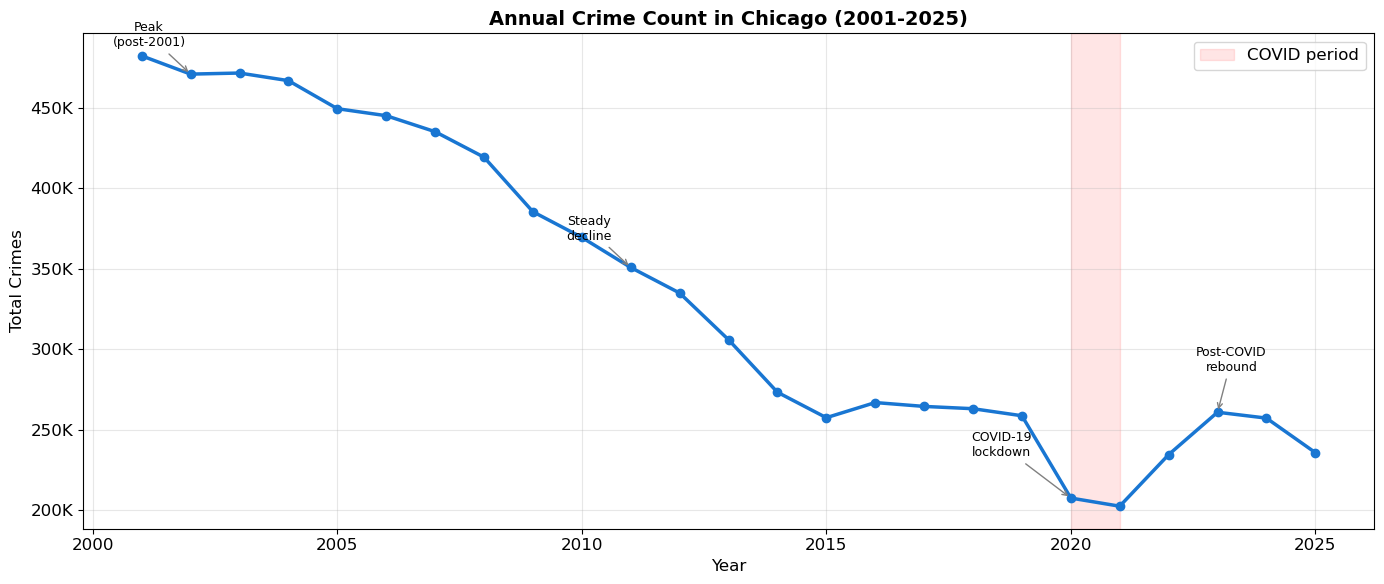

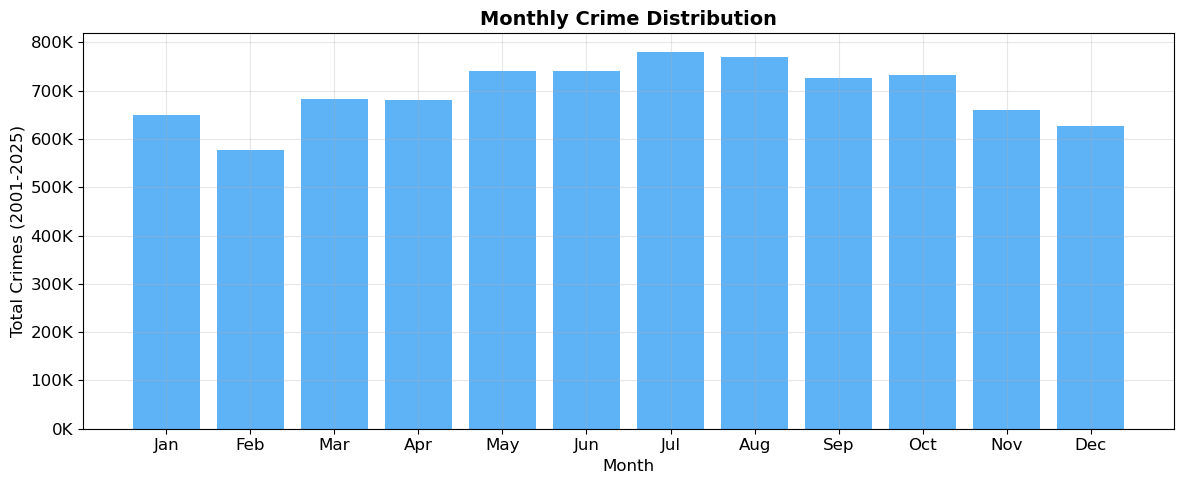

Peak: Jul (779,889)
Trough: Feb (576,959)
Peak/Trough ratio: 1.35x


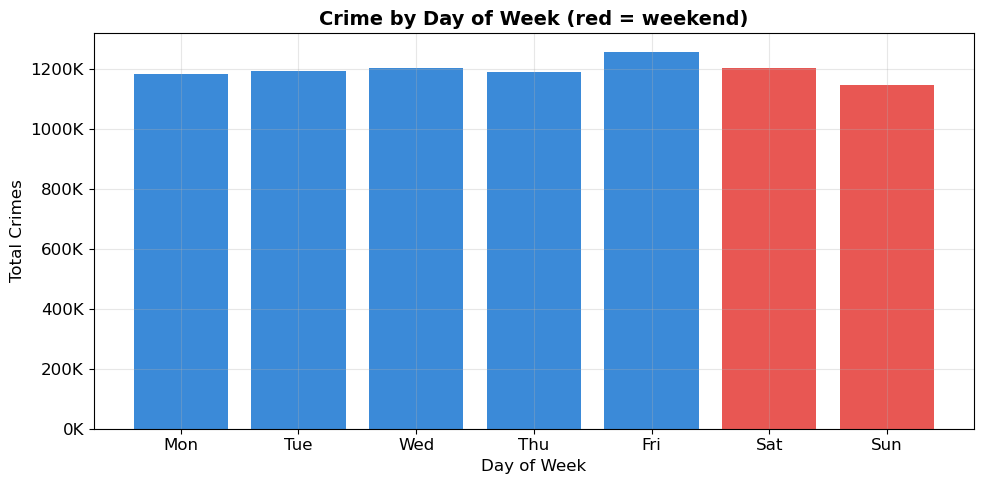

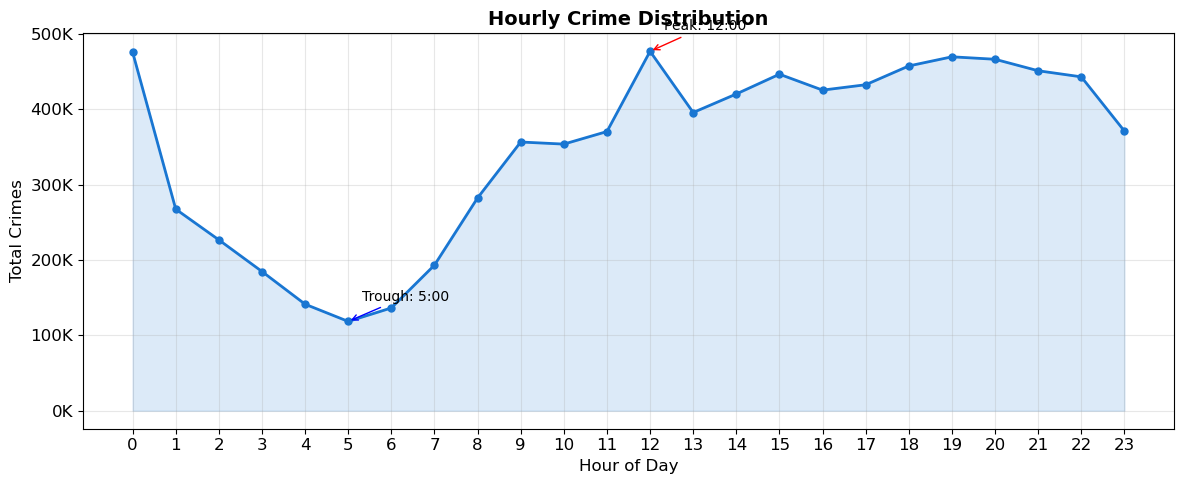

Crime category breakdown:
  Property      3,624,763 (43.3%)
  Violent       2,463,602 (29.4%)
  Other         2,279,427 (27.2%)


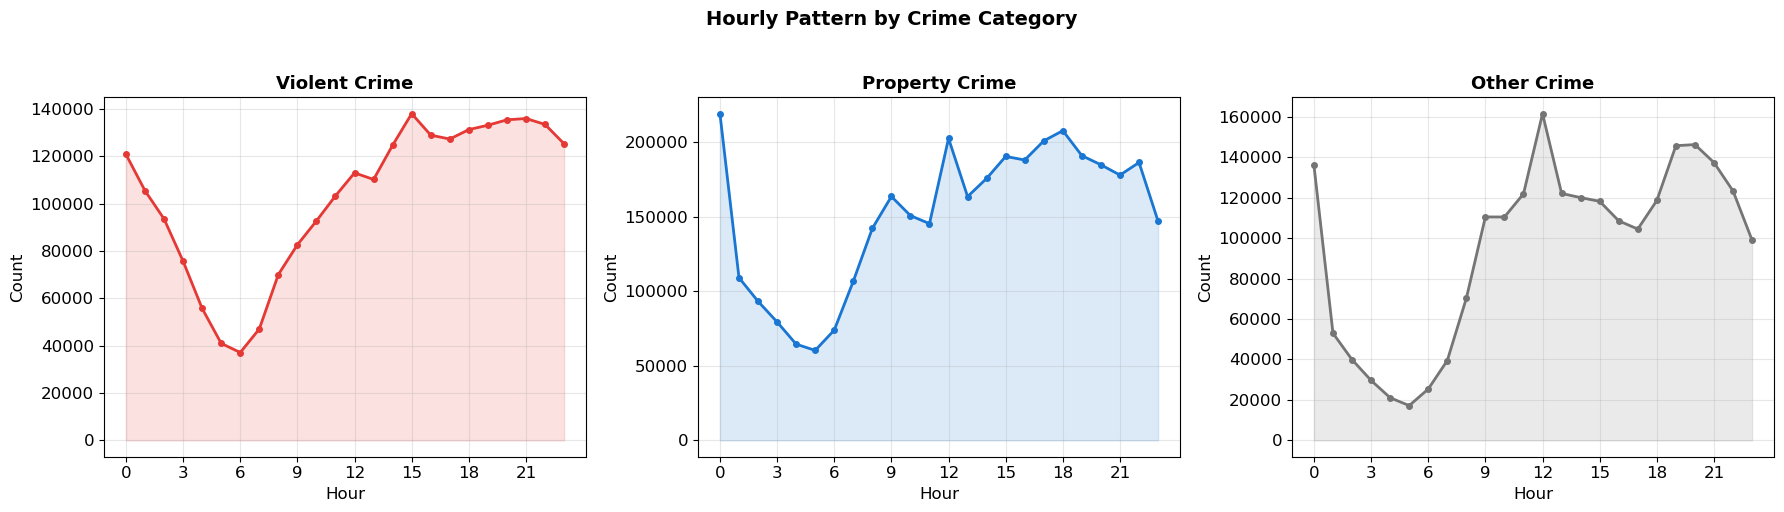

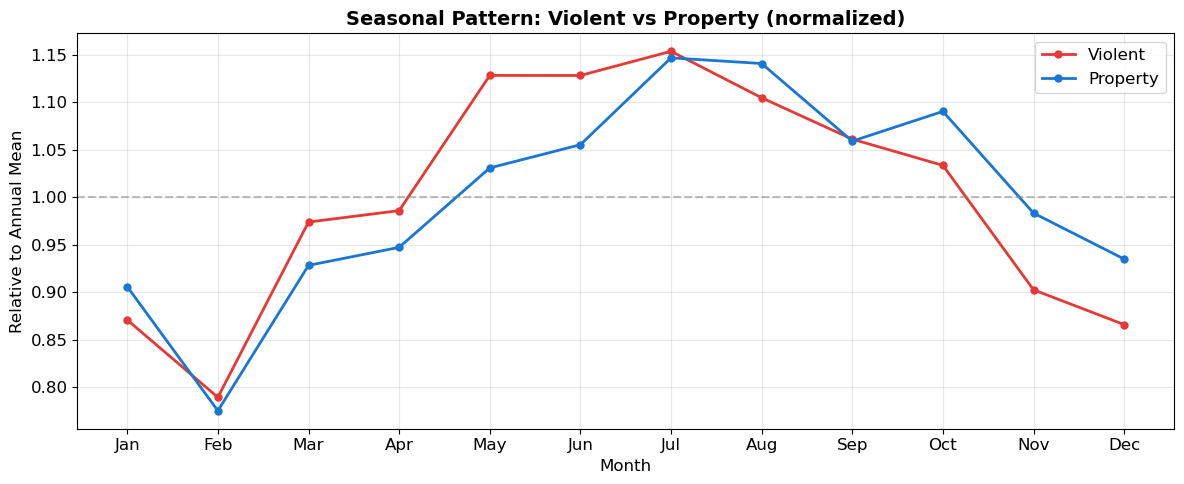

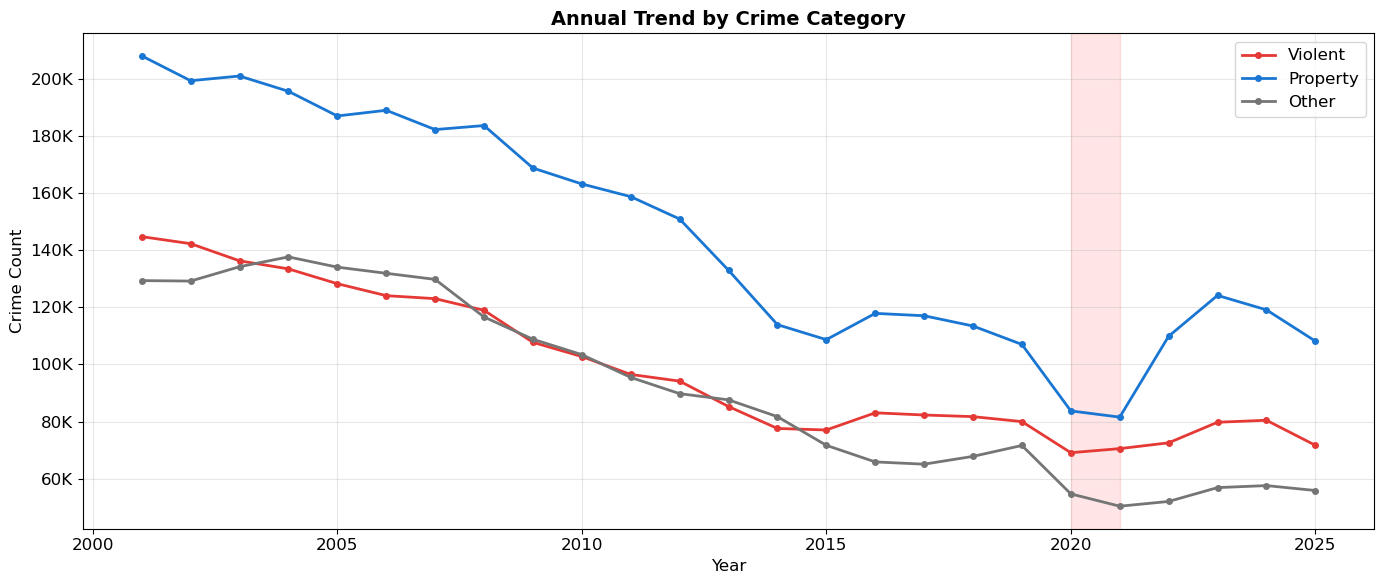

In [2]:
# Part 1: Temporal Patterns

# 1.1 Annual Trend

# %%
annual = df.groupby('year').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(annual['year'], annual['count'], 'o-', color='#1976D2', lw=2.5, ms=6, zorder=3)

annotations = {
    2002: ('Peak\n(post-2001)', -30, 20),
    2011: ('Steady\ndecline', -30, 20),
    2020: ('COVID-19\nlockdown', -50, 30),
    2023: ('Post-COVID\nrebound', 10, 30),
}
for yr, (label, xoff, yoff) in annotations.items():
    val = annual.loc[annual['year'] == yr, 'count'].values
    if len(val) > 0:
        ax.annotate(label, xy=(yr, val[0]),
                    xytext=(xoff, yoff), textcoords='offset points',
                    fontsize=9, ha='center',
                    arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('Year')
ax.set_ylabel('Total Crimes')
ax.set_title('Annual Crime Count in Chicago (2001-2025)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.axvspan(2020, 2021, alpha=0.1, color='red', label='COVID period')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '01_annual_trend.png'), dpi=150, bbox_inches='tight')
plt.show()

# 1.2 Monthly / Seasonal Pattern


monthly = df.groupby('month').size().reset_index(name='count')
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly['month'], monthly['count'], color='#42A5F5', alpha=0.85)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_xlabel('Month')
ax.set_ylabel('Total Crimes (2001-2025)')
ax.set_title('Monthly Crime Distribution', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '02_monthly_pattern.png'), dpi=150, bbox_inches='tight')
plt.show()

peak_month = monthly.loc[monthly['count'].idxmax()]
trough_month = monthly.loc[monthly['count'].idxmin()]
print(f"Peak: {month_labels[int(peak_month['month'])-1]} ({peak_month['count']:,.0f})")
print(f"Trough: {month_labels[int(trough_month['month'])-1]} ({trough_month['count']:,.0f})")
print(f"Peak/Trough ratio: {peak_month['count']/trough_month['count']:.2f}x")

# 1.3 Day-of-Week Effect

dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow = df.groupby('day_of_week').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1976D2']*5 + ['#E53935']*2
ax.bar(dow['day_of_week'], dow['count'], color=colors, alpha=0.85)
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Total Crimes')
ax.set_title('Crime by Day of Week (red = weekend)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '03_day_of_week.png'), dpi=150, bbox_inches='tight')
plt.show()

# 1.4 Hourly Pattern

hourly = df.groupby('hour').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly['hour'], hourly['count'], 'o-', color='#1976D2', lw=2, ms=5)
ax.fill_between(hourly['hour'], hourly['count'], alpha=0.15, color='#1976D2')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Total Crimes')
ax.set_title('Hourly Crime Distribution', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

peak_hr = hourly.loc[hourly['count'].idxmax()]
trough_hr = hourly.loc[hourly['count'].idxmin()]
ax.annotate(f"Peak: {int(peak_hr['hour'])}:00", xy=(peak_hr['hour'], peak_hr['count']),
            xytext=(10, 15), textcoords='offset points', fontsize=10,
            arrowprops=dict(arrowstyle='->', color='red'))
ax.annotate(f"Trough: {int(trough_hr['hour'])}:00", xy=(trough_hr['hour'], trough_hr['count']),
            xytext=(10, 15), textcoords='offset points', fontsize=10,
            arrowprops=dict(arrowstyle='->', color='blue'))

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '04_hourly_pattern.png'), dpi=150, bbox_inches='tight')
plt.show()

# 1.5 Temporal Patterns by Crime Category


violent_types = ['BATTERY', 'ASSAULT', 'HOMICIDE', 'ROBBERY',
                 'CRIM SEXUAL ASSAULT', 'CRIMINAL SEXUAL ASSAULT']
property_types = ['THEFT', 'BURGLARY', 'MOTOR VEHICLE THEFT',
                  'CRIMINAL DAMAGE', 'ARSON']

df['crime_category'] = 'Other'
df.loc[df['primary_type'].isin(violent_types), 'crime_category'] = 'Violent'
df.loc[df['primary_type'].isin(property_types), 'crime_category'] = 'Property'

cat_counts = df['crime_category'].value_counts()
print("Crime category breakdown:")
for cat, cnt in cat_counts.items():
    print(f"  {cat:<10s} {cnt:>12,} ({cnt/len(df)*100:.1f}%)")

# Hourly by category
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
categories = ['Violent', 'Property', 'Other']
colors_cat = {'Violent': '#E53935', 'Property': '#1976D2', 'Other': '#757575'}

for ax, cat in zip(axes, categories):
    sub = df[df['crime_category'] == cat].groupby('hour').size().reset_index(name='count')
    ax.plot(sub['hour'], sub['count'], 'o-', color=colors_cat[cat], lw=2, ms=4)
    ax.fill_between(sub['hour'], sub['count'], alpha=0.15, color=colors_cat[cat])
    ax.set_title(f'{cat} Crime', fontsize=13, fontweight='bold')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Count')
    ax.set_xticks(range(0, 24, 3))

plt.suptitle('Hourly Pattern by Crime Category', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '05_hourly_by_category.png'), dpi=150, bbox_inches='tight')
plt.show()


# Seasonal by category (normalized)
fig, ax = plt.subplots(figsize=(12, 5))
for cat in ['Violent', 'Property']:
    sub = df[df['crime_category'] == cat].groupby('month').size().reset_index(name='count')
    sub['norm'] = sub['count'] / sub['count'].mean()
    ax.plot(sub['month'], sub['norm'], 'o-', label=cat, color=colors_cat[cat], lw=2, ms=5)

ax.axhline(1.0, color='gray', ls='--', alpha=0.5)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_xlabel('Month')
ax.set_ylabel('Relative to Annual Mean')
ax.set_title('Seasonal Pattern: Violent vs Property (normalized)',
             fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '06_seasonal_by_category.png'), dpi=150, bbox_inches='tight')
plt.show()


# Annual trend by category
fig, ax = plt.subplots(figsize=(14, 6))
for cat in ['Violent', 'Property', 'Other']:
    sub = df[df['crime_category'] == cat].groupby('year').size().reset_index(name='count')
    ax.plot(sub['year'], sub['count'], 'o-', label=cat, color=colors_cat[cat], lw=2, ms=4)

ax.axvspan(2020, 2021, alpha=0.1, color='red')
ax.set_xlabel('Year')
ax.set_ylabel('Crime Count')
ax.set_title('Annual Trend by Crime Category', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '07_annual_by_category.png'), dpi=150, bbox_inches='tight')
plt.show()


In [3]:
pip install geopanda

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
    --------------------------------------- 0.5/22.9 MB 2.5 MB/s eta 0:00:09
   --- ------------------------------------ 1.8/22.9 MB 4.6 MB/s eta 0:00:05
   -------- ------------------------------- 4.7/22.9 MB 8.2 MB/s eta 0:00:03
   -------------- ------------------------- 8.1/22.9 MB 10.6 MB/s eta 0:00:02
   --------------------- ------------------ 12.1/22.9 MB 12.3 MB/s eta 0:00:01
   --------------------------- ------------ 15.7/22.9 MB 13.4 MB/s eta 0:00:01
   --------------------------------- ------ 19.4/22.9 MB 14.1 MB/s eta 0:00:01
   ---------------------------------------  22.8/22.9 MB 14.7 MB/s eta 0:00:01
   ---------------------------------------- 22.9/22.9 MB 14.4 MB/s  0:00:01
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ----------------------- ---------------- 3.7/6.3 MB 17.9 MB/s eta 0:00:01
   --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Loaded GeoJSON: 77 community areas
Area number column: 'area_numbe'
Name column: 'community'


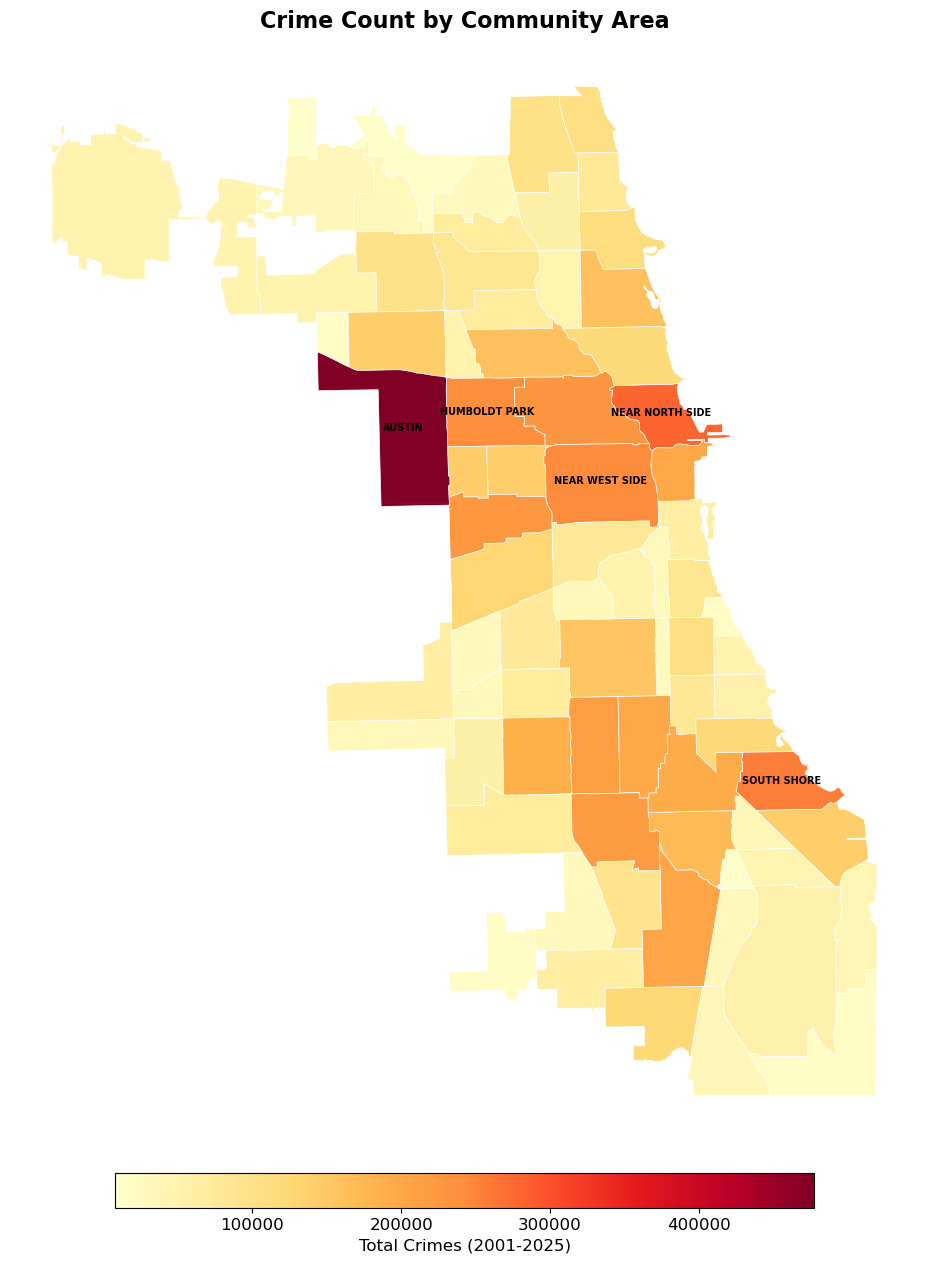

Top 10 Community Areas:
   1. AUSTIN                         477,519
   2. NEAR NORTH SIDE                279,992
   3. SOUTH SHORE                    257,100
   4. NEAR WEST SIDE                 242,867
   5. HUMBOLDT PARK                  239,763
   6. WEST TOWN                      228,242
   7. NORTH LAWNDALE                 224,577
   8. AUBURN GRESHAM                 218,884
   9. WEST ENGLEWOOD                 215,518
  10. ROSELAND                       204,014

Bottom 10:
   1. EDISON PARK                      7,804
   2. BURNSIDE                        11,429
   3. FOREST GLEN                     14,494
   4. MOUNT GREENWOOD                 17,401
   5. HEGEWISCH                       17,847
   6. OAKLAND                         18,617
   7. MONTCLARE                       18,758
   8. FULLER PARK                     25,512
   9. NORTH PARK                      26,607
  10. BEVERLY                         28,373


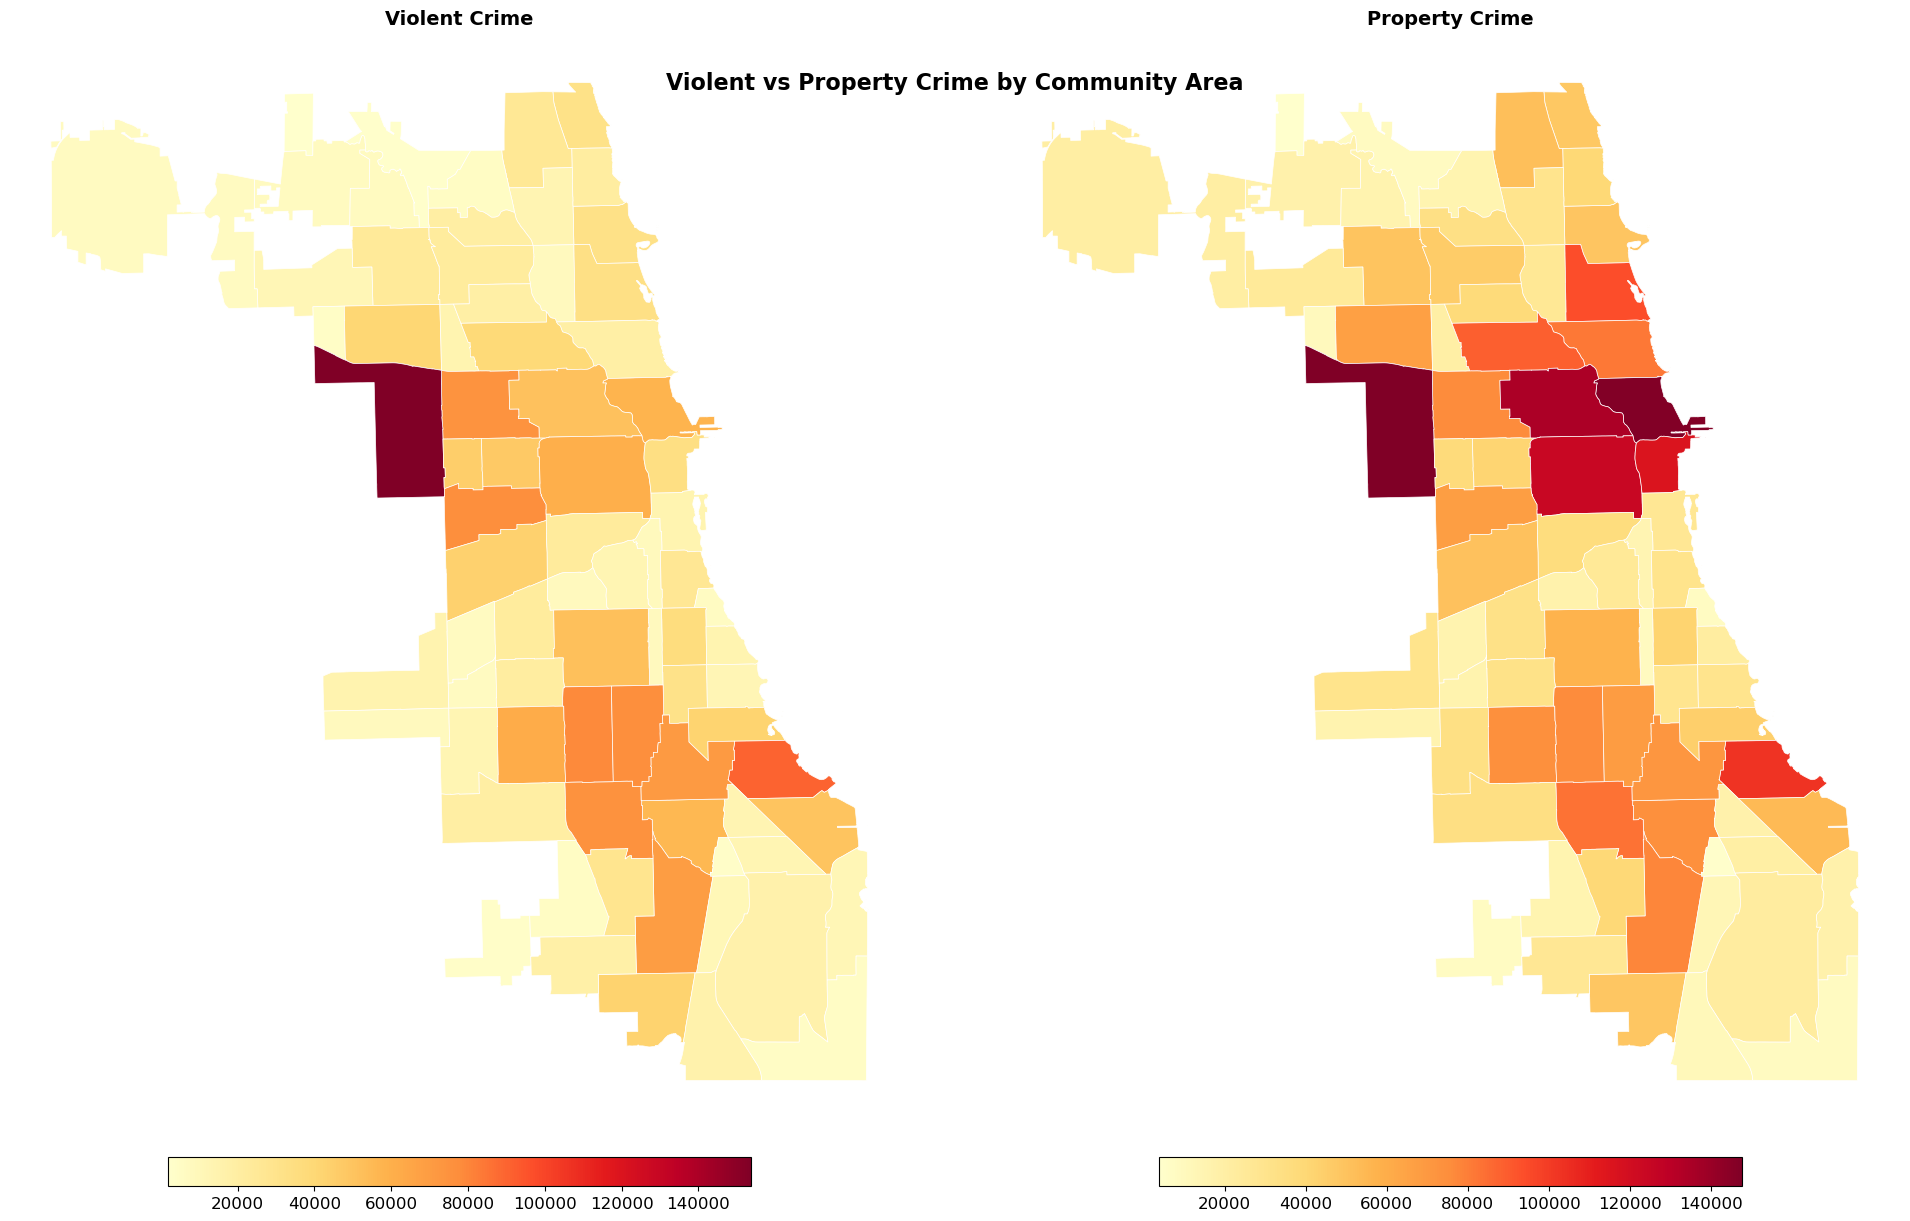

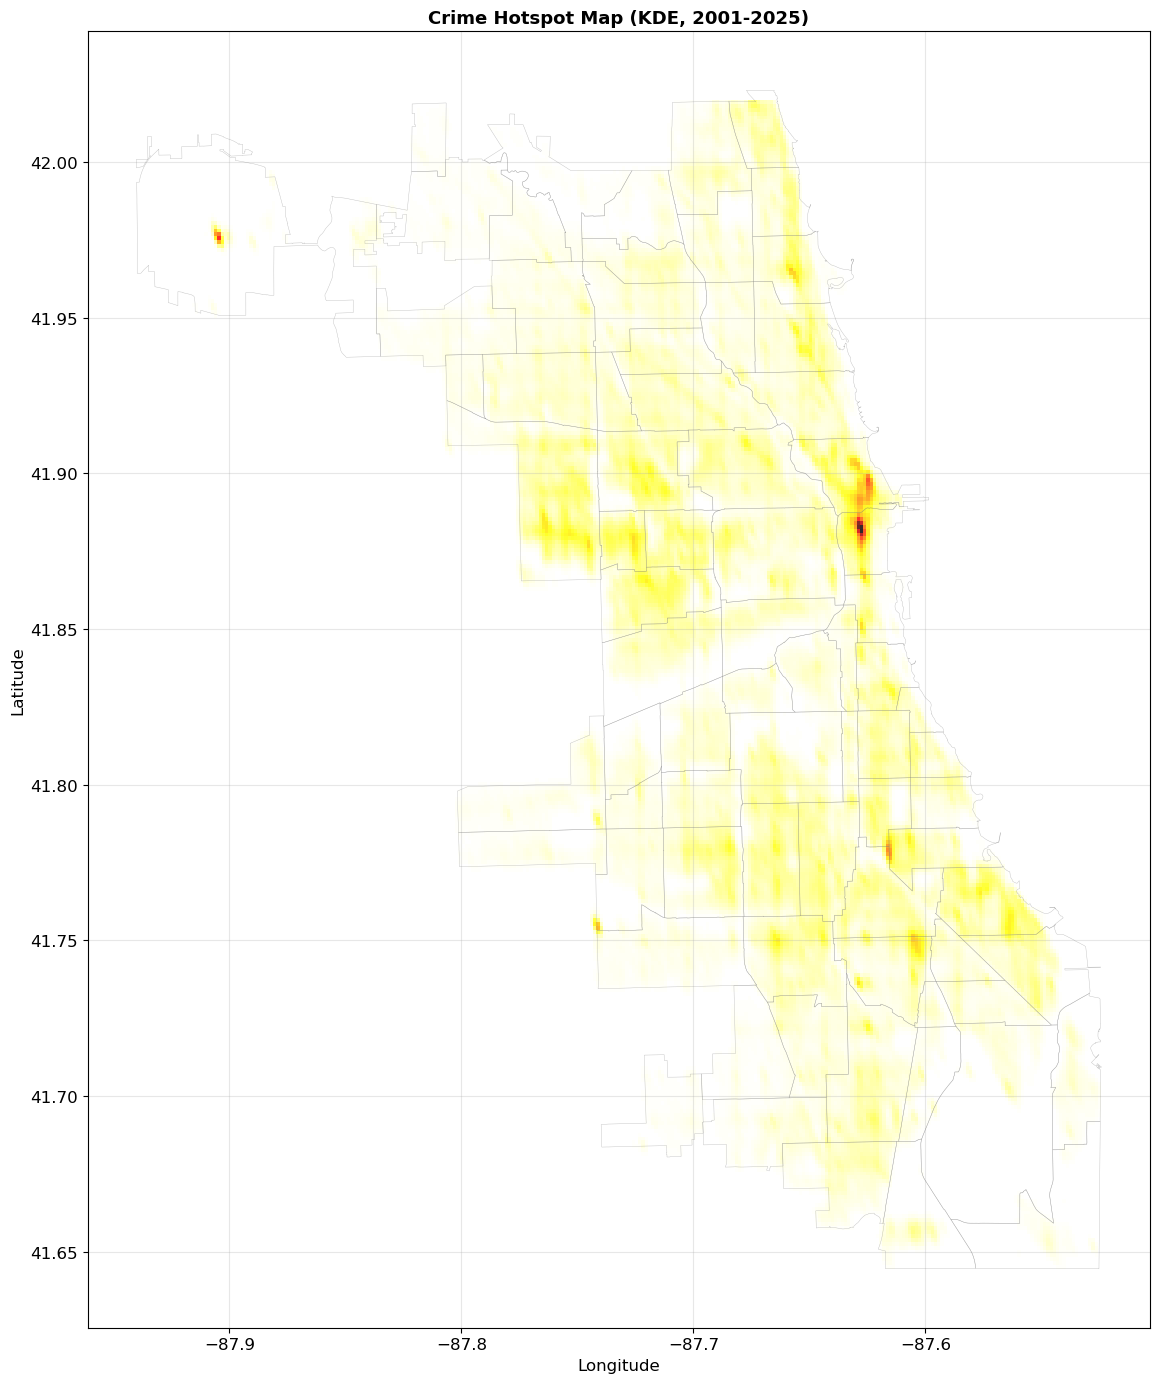

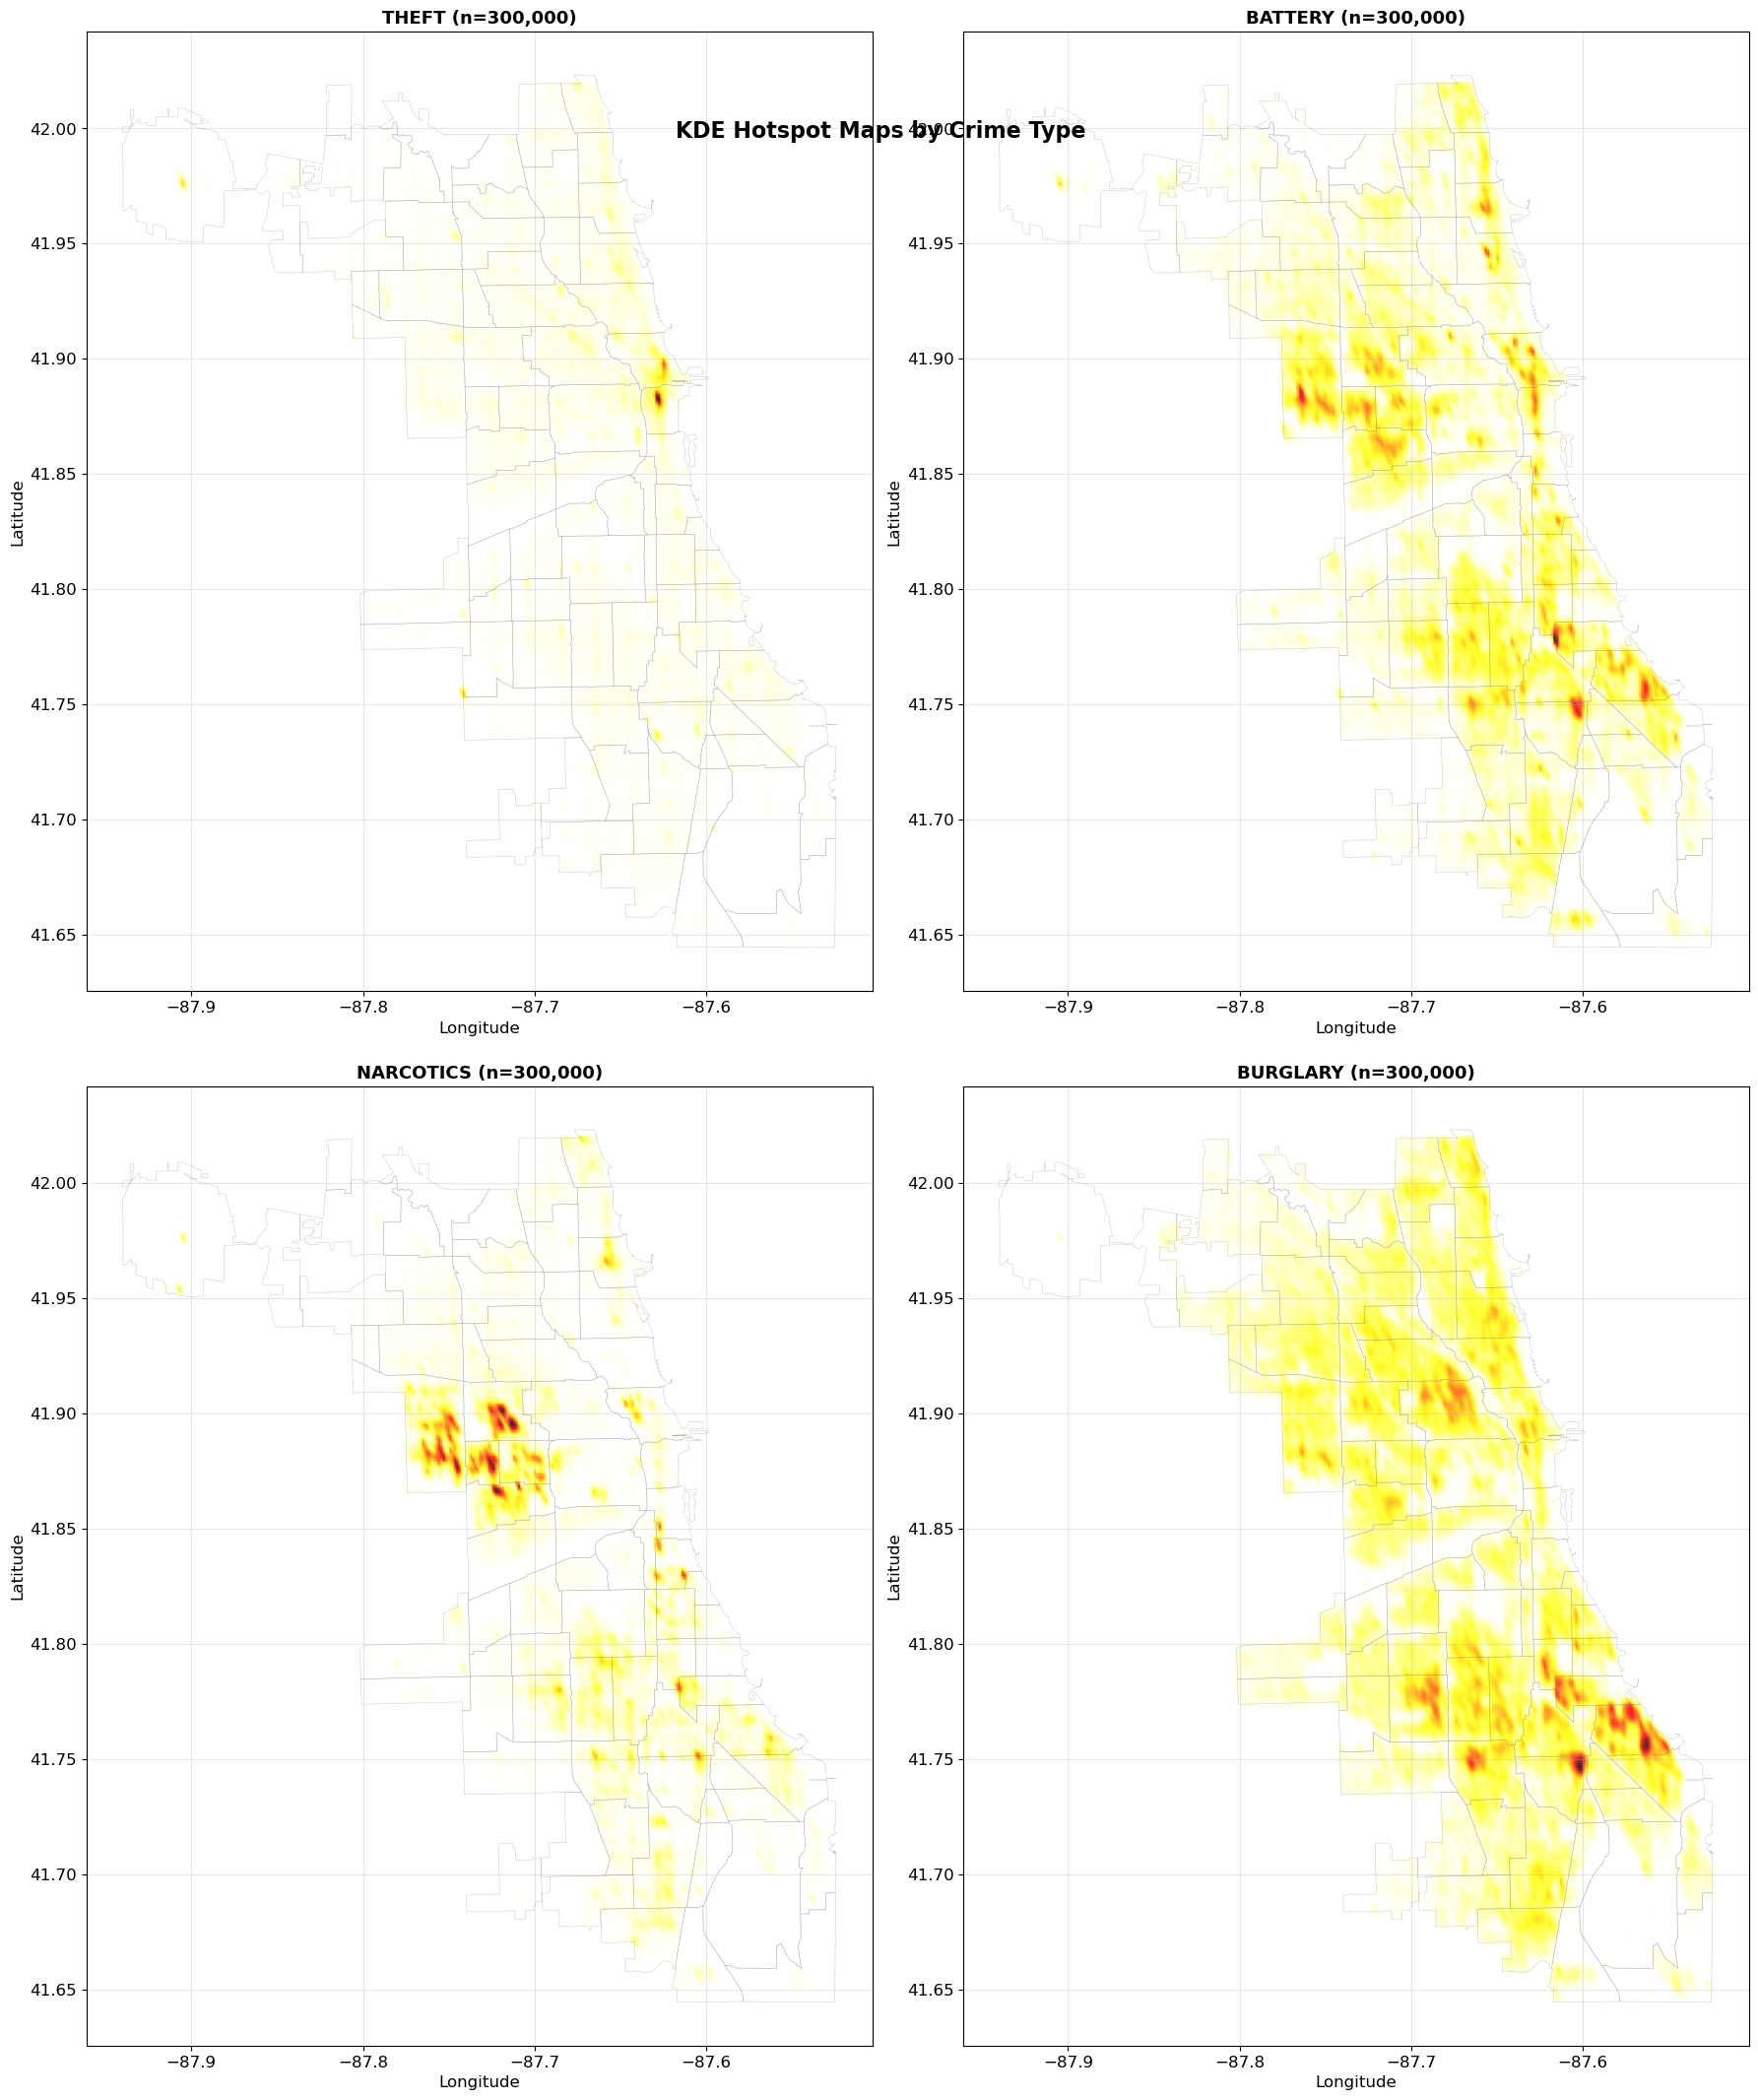

In [5]:
# Part 2: Spatial Patterns
#Download Chicago community area boundaries.

# 2.1 Load Community Area Boundaries


import geopandas as gpd

GEOJSON_PATH = './data/community_areas.geojson'
SHP_DIR = './data/community_areas/'

if os.path.exists(GEOJSON_PATH):
    gdf_ca = gpd.read_file(GEOJSON_PATH)
    print(f"Loaded GeoJSON: {len(gdf_ca)} community areas")
elif os.path.exists(SHP_DIR):
    shp_files = [f for f in os.listdir(SHP_DIR) if f.endswith('.shp')]
    if shp_files:
        gdf_ca = gpd.read_file(os.path.join(SHP_DIR, shp_files[0]))
        print(f"Loaded Shapefile: {len(gdf_ca)} community areas")
    else:
        raise FileNotFoundError("No .shp found in " + SHP_DIR)
else:
    raise FileNotFoundError(
        "Community area boundary file not found.\n"
        "Download GeoJSON from:\n"
        "https://data.cityofchicago.org/api/geospatial/cauq-8yn6?method=export&type=GeoJSON\n"
        "Save as ./data/community_areas.geojson"
    )

# Identify key columns
ca_num_col = None
for col in gdf_ca.columns:
    if 'area_num' in col.lower():
        ca_num_col = col
        break

name_col = None
for col in gdf_ca.columns:
    if 'community' in col.lower() and ('name' in col.lower() or col.lower() == 'community'):
        name_col = col
        break

if ca_num_col:
    gdf_ca[ca_num_col] = pd.to_numeric(gdf_ca[ca_num_col], errors='coerce')
    print(f"Area number column: '{ca_num_col}'")
if name_col:
    print(f"Name column: '{name_col}'")

gdf_ca.head(3)

# 2.2 Crime Count Choropleth Map


ca_crimes = df.groupby('community_area').size().reset_index(name='total_crimes')
ca_crimes['community_area'] = ca_crimes['community_area'].astype(float)

gdf_map = gdf_ca.merge(ca_crimes, left_on=ca_num_col, right_on='community_area', how='left')
gdf_map['total_crimes'] = gdf_map['total_crimes'].fillna(0)

fig, ax = plt.subplots(1, 1, figsize=(12, 14))
gdf_map.plot(column='total_crimes', cmap='YlOrRd', edgecolor='white',
             linewidth=0.5, legend=True, ax=ax,
             legend_kwds={'label': 'Total Crimes (2001-2025)',
                          'orientation': 'horizontal',
                          'shrink': 0.6, 'pad': 0.02})
ax.set_title('Crime Count by Community Area', fontsize=16, fontweight='bold')
ax.axis('off')

if name_col:
    top5 = gdf_map.nlargest(5, 'total_crimes')
    for _, row in top5.iterrows():
        c = row.geometry.centroid
        ax.annotate(row[name_col], xy=(c.x, c.y),
                    fontsize=7, ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '08_choropleth_total.png'), dpi=150, bbox_inches='tight')
plt.show()

# %%
print("Top 10 Community Areas:")
for i, (_, r) in enumerate(gdf_map.nlargest(10, 'total_crimes').iterrows(), 1):
    nm = r[name_col] if name_col else f"CA {r[ca_num_col]:.0f}"
    print(f"  {i:>2d}. {nm:<25s} {r['total_crimes']:>12,.0f}")

print("\nBottom 10:")
for i, (_, r) in enumerate(gdf_map.nsmallest(10, 'total_crimes').iterrows(), 1):
    nm = r[name_col] if name_col else f"CA {r[ca_num_col]:.0f}"
    print(f"  {i:>2d}. {nm:<25s} {r['total_crimes']:>12,.0f}")

# 2.3 Choropleth by Crime Category


fig, axes = plt.subplots(1, 2, figsize=(20, 14))

for ax, cat in zip(axes, ['Violent', 'Property']):
    sub = df[df['crime_category'] == cat]
    ca_sub = sub.groupby('community_area').size().reset_index(name='count')
    ca_sub['community_area'] = ca_sub['community_area'].astype(float)
    gdf_sub = gdf_ca.merge(ca_sub, left_on=ca_num_col, right_on='community_area', how='left')
    gdf_sub['count'] = gdf_sub['count'].fillna(0)
    gdf_sub.plot(column='count', cmap='YlOrRd', edgecolor='white',
                 linewidth=0.5, legend=True, ax=ax,
                 legend_kwds={'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.02})
    ax.set_title(f'{cat} Crime', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('Violent vs Property Crime by Community Area',
             fontsize=16, fontweight='bold', y=0.93)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '09_choropleth_by_category.png'), dpi=150, bbox_inches='tight')
plt.show()

# 2.4 KDE Hotspot Map

# Kernel Density Estimation on raw lat/lon coordinates produces a continuous
# density surface — the standard crime hotspot visualization


# %%
from scipy.stats import gaussian_kde

def plot_kde_hotspot(lats, lons, title, ax, bw_method=0.02, n_grid=300):
    """KDE hotspot map with community area boundary overlay."""
    coords = np.vstack([lons, lats])
    kde = gaussian_kde(coords, bw_method=bw_method)

    xmin, xmax = lons.min(), lons.max()
    ymin, ymax = lats.min(), lats.max()
    xx, yy = np.mgrid[xmin:xmax:complex(n_grid), ymin:ymax:complex(n_grid)]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    zz = np.reshape(kde(positions), xx.shape)

    ax.imshow(np.rot90(zz), extent=[xmin, xmax, ymin, ymax],
              cmap='hot_r', aspect='auto', alpha=0.85)

    if 'gdf_ca' in globals():
        gdf_ca.boundary.plot(ax=ax, color='gray', linewidth=0.3, alpha=0.5)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# %%
np.random.seed(42)
sample_size = min(800_000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)

fig, ax = plt.subplots(figsize=(12, 14))
plot_kde_hotspot(df_sample['latitude'].values, df_sample['longitude'].values,
                 'Crime Hotspot Map (KDE, 2001-2025)', ax)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '10_kde_hotspot_all.png'), dpi=150, bbox_inches='tight')
plt.show()

# 2.5 KDE by Crime Type


compare_types = ['THEFT', 'BATTERY', 'NARCOTICS', 'BURGLARY']
fig, axes = plt.subplots(2, 2, figsize=(18, 22))

for ax, ctype in zip(axes.ravel(), compare_types):
    sub = df[df['primary_type'] == ctype]
    if len(sub) > 300_000:
        sub = sub.sample(n=300_000, random_state=42)
    plot_kde_hotspot(sub['latitude'].values, sub['longitude'].values,
                     f'{ctype} (n={len(sub):,})', ax)

plt.suptitle('KDE Hotspot Maps by Crime Type', fontsize=16, fontweight='bold', y=0.92)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '11_kde_by_crime_type.png'), dpi=150, bbox_inches='tight')
plt.show()


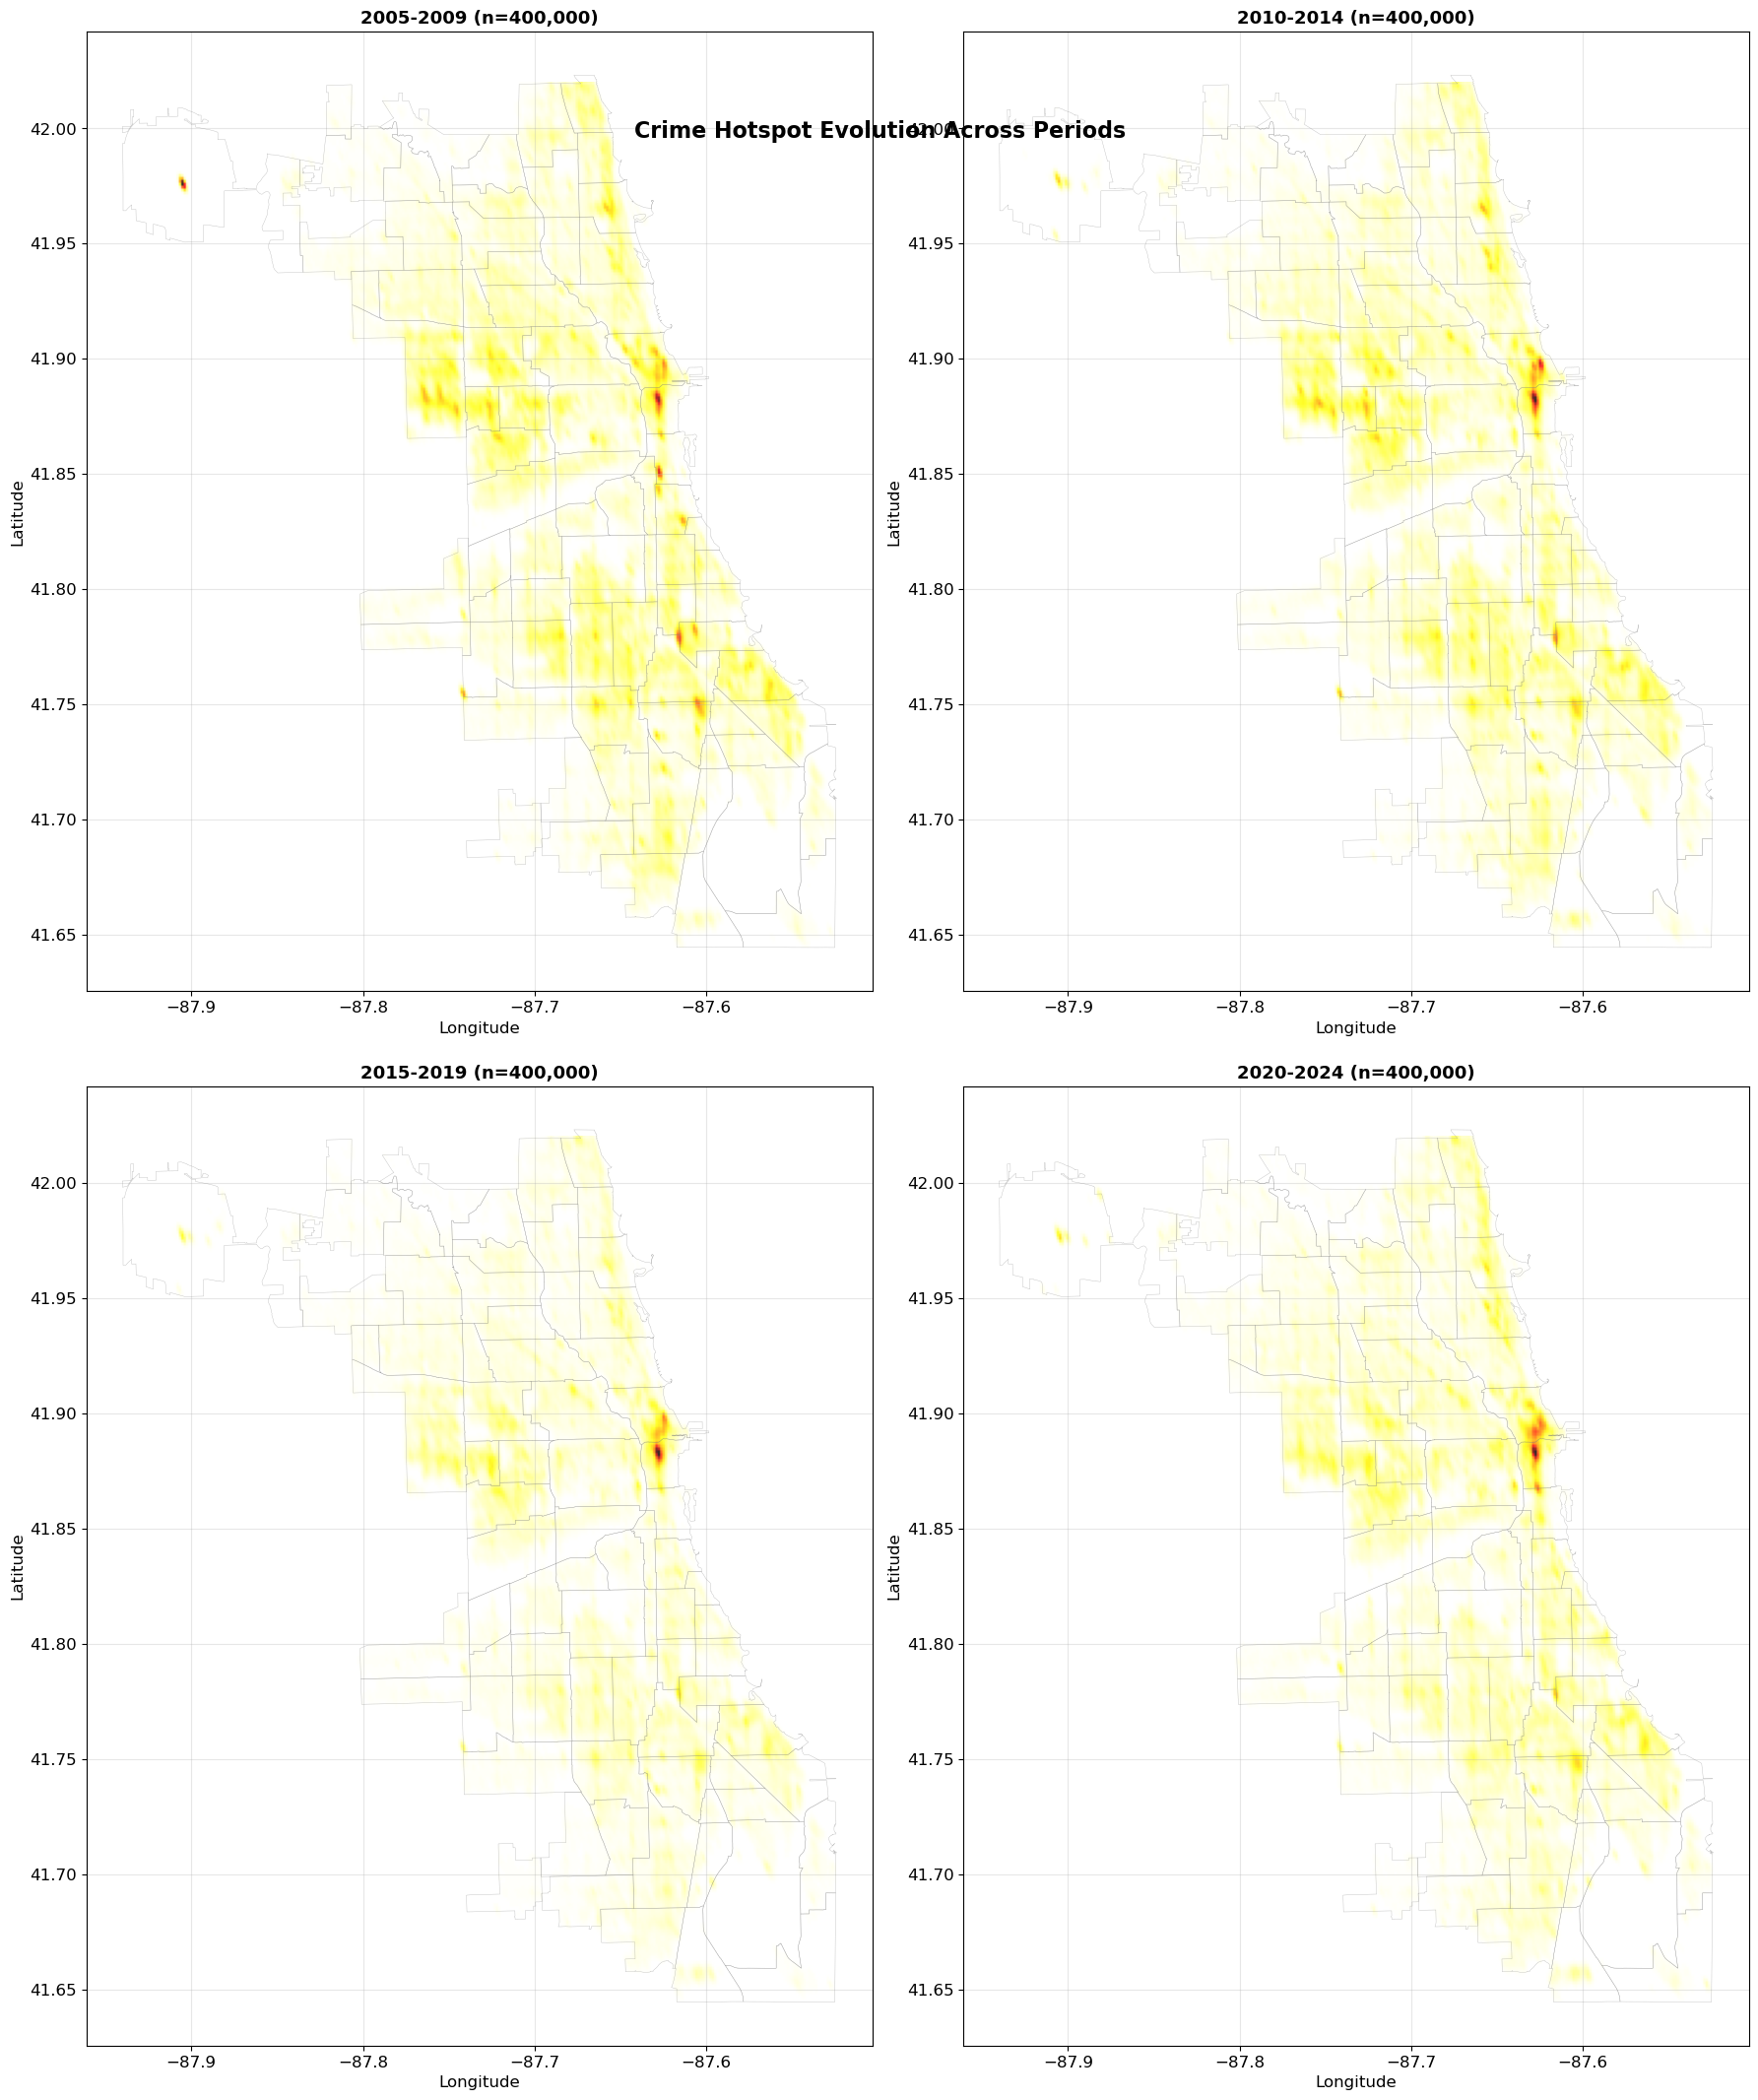

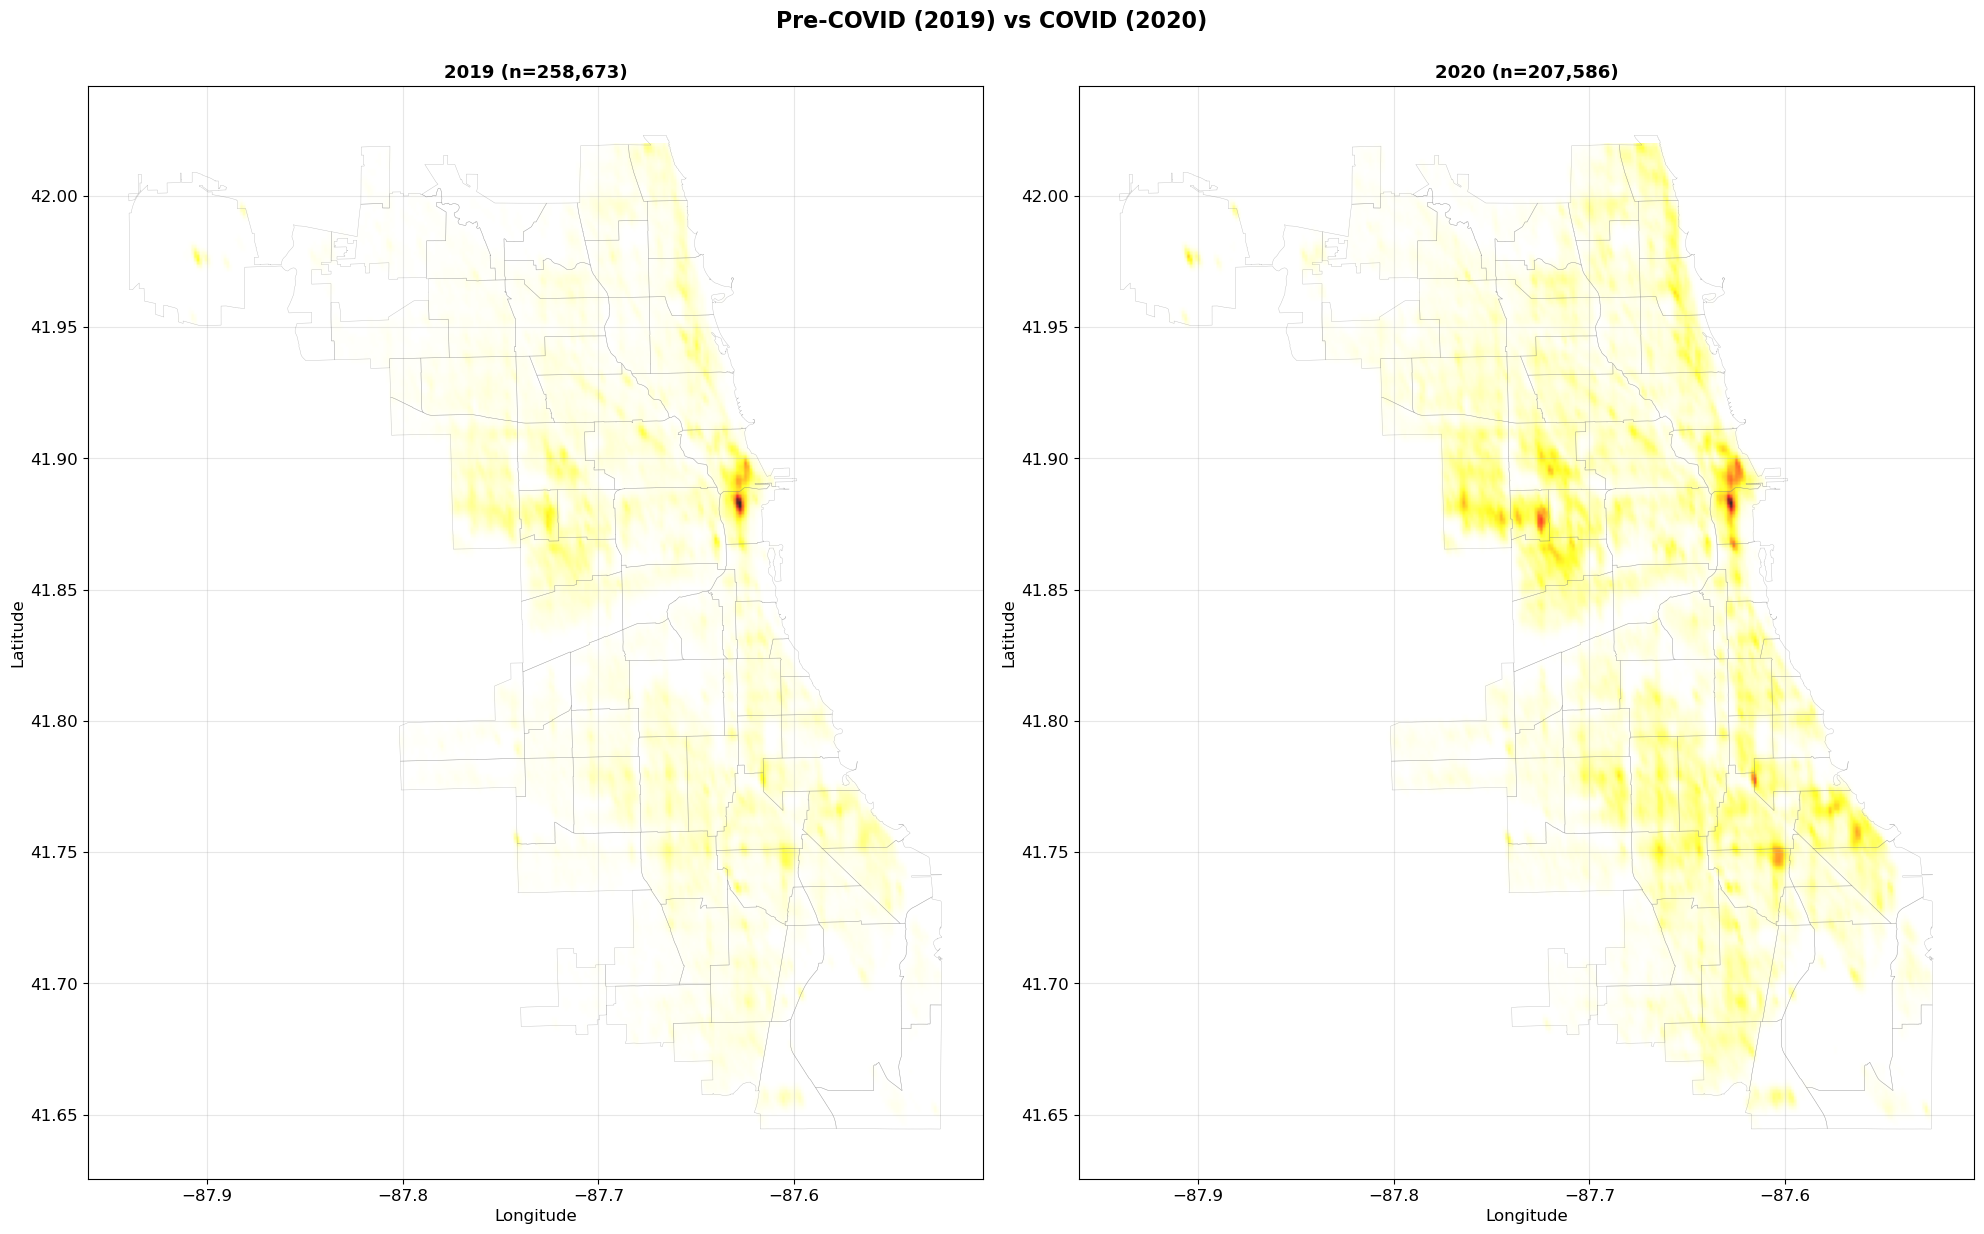

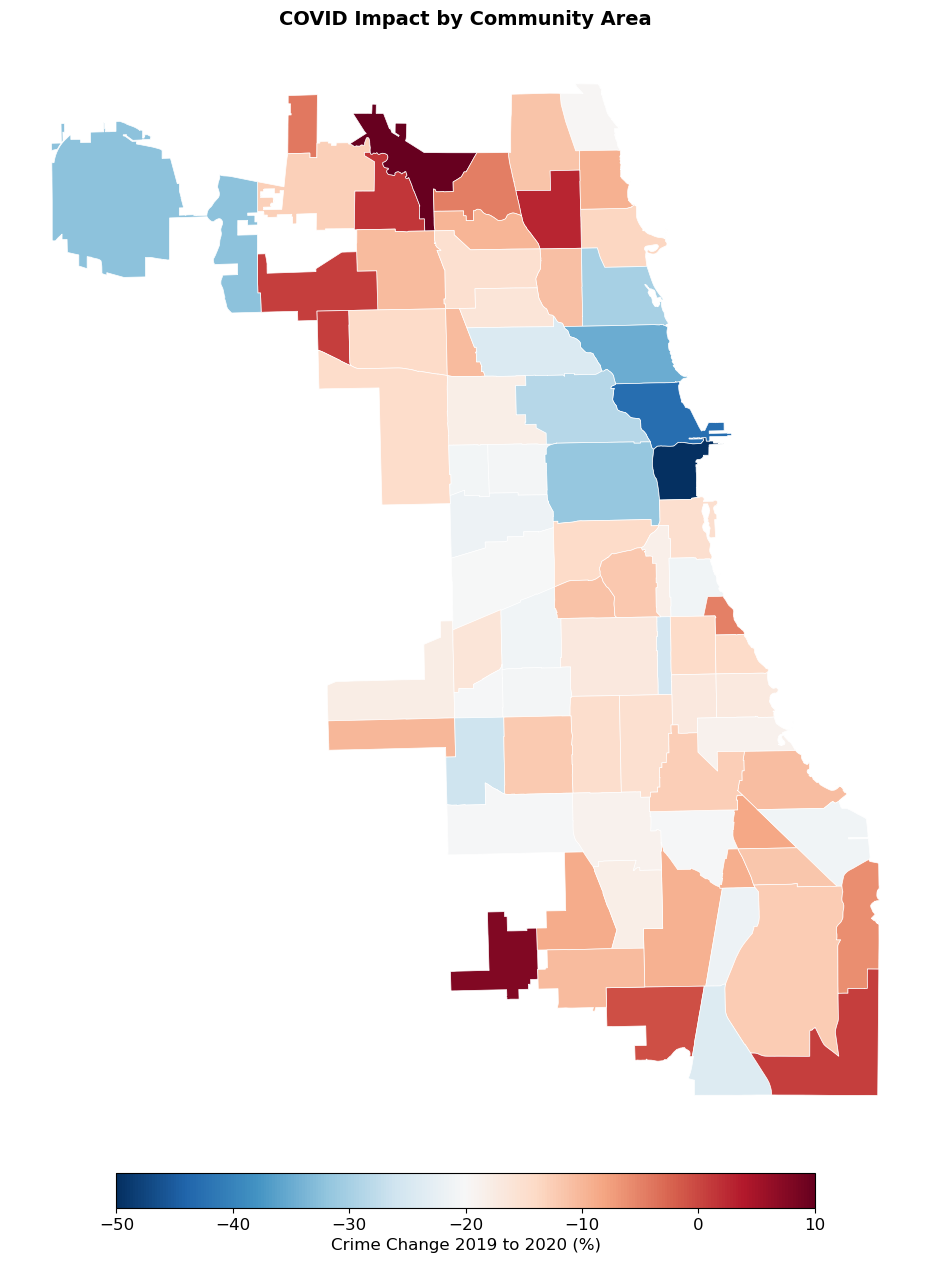

Mean change: -15.1%
Median change: -14.7%

Most decreased:
  CA 32: -52.1%
  CA 8: -42.9%
  CA 7: -34.9%
  CA 76: -32.3%
  CA 28: -31.5%
Least decreased / increased:
  CA 12: +19.6%
  CA 74: +7.7%
  CA 4: +2.8%
  CA 11: +1.5%
  CA 55: +0.8%


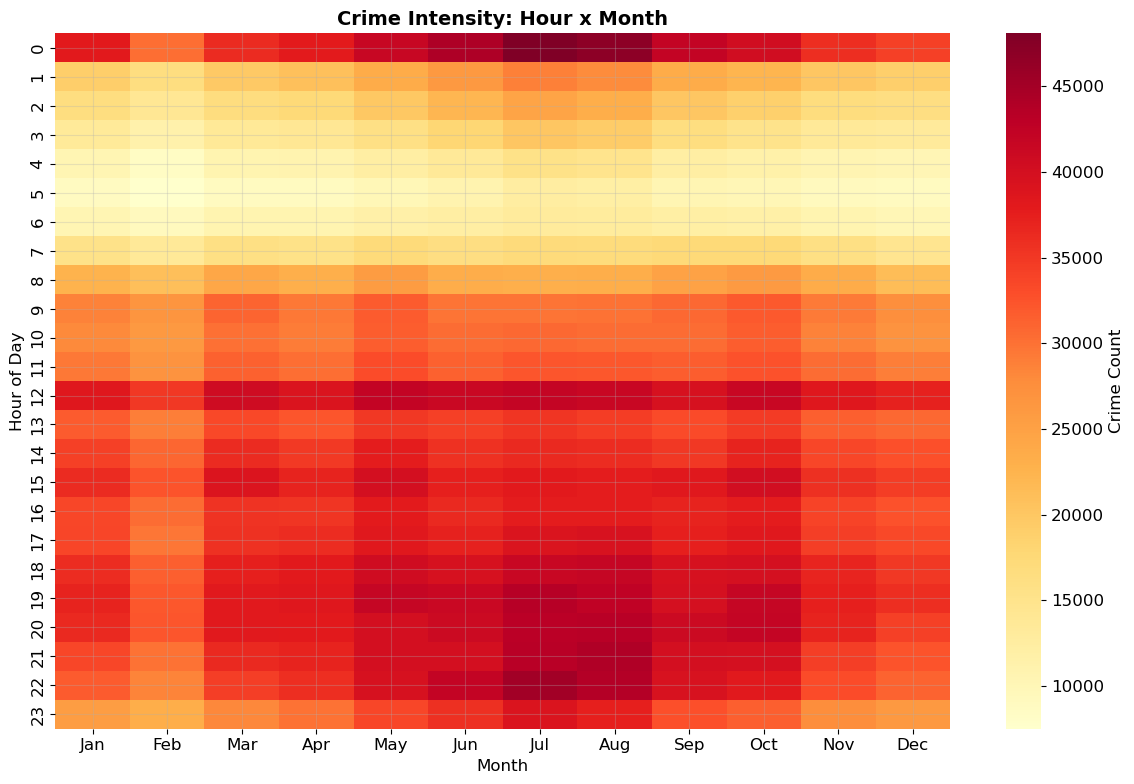

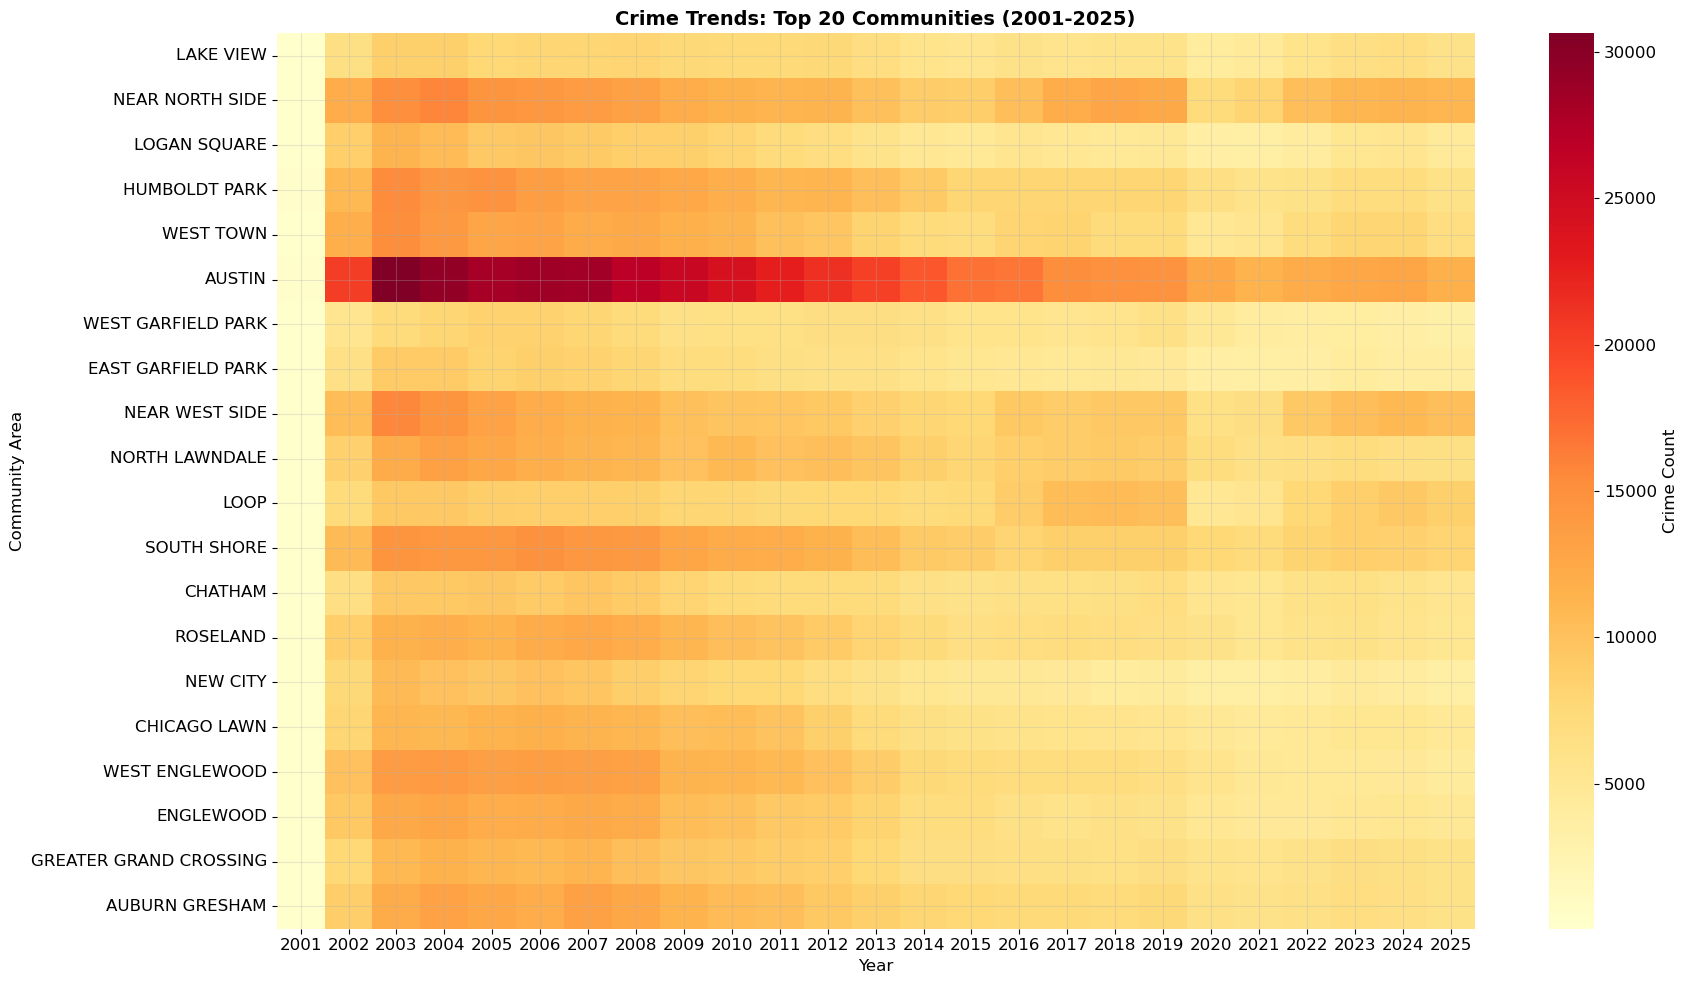

In [6]:
# Part 3: Spatiotemporal Interaction
# 3.1 Hotspot Evolution Over Time


periods = {
    '2005-2009': (2005, 2009),
    '2010-2014': (2010, 2014),
    '2015-2019': (2015, 2019),
    '2020-2024': (2020, 2024),
}

fig, axes = plt.subplots(2, 2, figsize=(18, 22))

for ax, (label, (y1, y2)) in zip(axes.ravel(), periods.items()):
    sub = df[(df['year'] >= y1) & (df['year'] <= y2)]
    if len(sub) > 400_000:
        sub = sub.sample(n=400_000, random_state=42)
    plot_kde_hotspot(sub['latitude'].values, sub['longitude'].values,
                     f'{label} (n={len(sub):,})', ax)

plt.suptitle('Crime Hotspot Evolution Across Periods',
             fontsize=16, fontweight='bold', y=0.92)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '12_hotspot_evolution.png'), dpi=150, bbox_inches='tight')
plt.show()

# 3.2 COVID Impact: 2019 vs 2020


fig, axes = plt.subplots(1, 2, figsize=(20, 14))

for ax, year in zip(axes, [2019, 2020]):
    sub = df[df['year'] == year]
    plot_kde_hotspot(sub['latitude'].values, sub['longitude'].values,
                     f'{year} (n={len(sub):,})', ax)

plt.suptitle('Pre-COVID (2019) vs COVID (2020)',
             fontsize=16, fontweight='bold', y=0.93)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '13_covid_spatial_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


# Community-level 2019 vs 2020 change map
ca_2019 = df[df['year'] == 2019].groupby('community_area').size().reset_index(name='y2019')
ca_2020 = df[df['year'] == 2020].groupby('community_area').size().reset_index(name='y2020')
ca_comp = ca_2019.merge(ca_2020, on='community_area', how='outer').fillna(0)
ca_comp['change_pct'] = (ca_comp['y2020'] - ca_comp['y2019']) / ca_comp['y2019'] * 100
ca_comp['community_area'] = ca_comp['community_area'].astype(float)

gdf_change = gdf_ca.merge(ca_comp, left_on=ca_num_col, right_on='community_area', how='left')

fig, ax = plt.subplots(figsize=(12, 14))
gdf_change.plot(column='change_pct', cmap='RdBu_r', edgecolor='white',
                linewidth=0.5, legend=True, ax=ax, vmin=-50, vmax=10,
                legend_kwds={'label': 'Crime Change 2019 to 2020 (%)',
                             'orientation': 'horizontal',
                             'shrink': 0.6, 'pad': 0.02})
ax.set_title('COVID Impact by Community Area', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '14_covid_change_map.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean change: {ca_comp['change_pct'].mean():.1f}%")
print(f"Median change: {ca_comp['change_pct'].median():.1f}%")
print("\nMost decreased:")
for _, r in ca_comp.nsmallest(5, 'change_pct').iterrows():
    print(f"  CA {r['community_area']:.0f}: {r['change_pct']:+.1f}%")
print("Least decreased / increased:")
for _, r in ca_comp.nlargest(5, 'change_pct').iterrows():
    print(f"  CA {r['community_area']:.0f}: {r['change_pct']:+.1f}%")

# 3.3 Hour x Month Heatmap


hm = df.groupby(['month', 'hour']).size().reset_index(name='count')
hm_pivot = hm.pivot(index='hour', columns='month', values='count').fillna(0)
hm_pivot.columns = month_labels

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(hm_pivot, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Crime Count'})
ax.set_xlabel('Month')
ax.set_ylabel('Hour of Day')
ax.set_title('Crime Intensity: Hour x Month', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '15_hour_month_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

# 3.4 Year x Community Area Heatmap

top20_ca = df.groupby('community_area').size().nlargest(20).index.tolist()
sub_top = df[df['community_area'].isin(top20_ca)]

ya = sub_top.groupby(['year', 'community_area']).size().reset_index(name='count')
ya_pivot = ya.pivot(index='community_area', columns='year', values='count').fillna(0)

if name_col and ca_num_col:
    ca_names = gdf_ca.set_index(ca_num_col)[name_col].to_dict()
    ya_pivot.index = [ca_names.get(ca, f'CA {ca:.0f}') for ca in ya_pivot.index]

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(ya_pivot, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Crime Count'})
ax.set_xlabel('Year')
ax.set_ylabel('Community Area')
ax.set_title('Crime Trends: Top 20 Communities (2001-2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '16_year_community_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()